In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
df = pd.read_csv(r"E:\credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [127]:
df.shape

(32581, 12)

In [128]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

In [129]:
df.rename(columns={'cb_person_default_on_file':'past_default_status'},inplace=True)

In [130]:
df.rename(columns={'cb_person_cred_hist_length':'cred_hist_length'},inplace=True)

### Check missing values

In [131]:
df.isnull().sum()

person_age                  0
person_income               0
person_home_ownership       0
person_emp_length         895
loan_intent                 0
loan_grade                  0
loan_amnt                   0
loan_int_rate            3116
loan_status                 0
loan_percent_income         0
past_default_status         0
cred_hist_length            0
dtype: int64

### Data Cleaning - Analysis of numerical columns

In [132]:
y = df['person_age'].sort_values(ascending=False).head(20)
z= df['person_age'].min()
print(f"Minimum person age {z}")
print(y)

Minimum person age 20
81       144
183      144
32297    144
575      123
747      123
32416     94
32506     84
32422     80
32355     78
32534     76
32432     73
32381     73
32521     73
32522     70
32532     70
32360     70
32383     70
32436     70
32334     70
32385     70
Name: person_age, dtype: int64


### here minimum age 20 is considered realistic but we should remove records where age is greater than 75

In [133]:
df = df[(df['person_age'] >= 18) & (df['person_age'] <= 75)]

### person_emp_length

In [134]:
emp_null = df['person_emp_length'].isnull().sum()
emp_null

np.int64(895)

### Here , 895 rows are null which are less than 3k , so we impute it with median value

In [135]:
df['person_emp_length'].fillna(df['person_emp_length'].median(),inplace=True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8944\258519556.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(),inplace=True)


In [136]:
loan_int = df['loan_int_rate'].isnull().sum()
loan_int

np.int64(3114)

In [137]:
### 3114 rows are null , so dropping them we might lose important information , so we impute them 
### let's check if it has strong relation with any other variable

In [138]:
df.corr(numeric_only=True)['loan_int_rate'].sort_values(ascending=False)

loan_int_rate          1.000000
loan_status            0.335145
loan_amnt              0.146877
loan_percent_income    0.120375
cred_hist_length       0.017075
person_age             0.012771
person_income         -0.001231
person_emp_length     -0.053498
Name: loan_int_rate, dtype: float64

In [139]:
df.groupby('loan_grade')['loan_int_rate'].mean().sort_values()

loan_grade
A     7.327449
B    10.995466
C    13.463649
D    15.361448
E    17.009455
F    18.609159
G    20.251525
Name: loan_int_rate, dtype: float64

In [140]:
### here we can see that loan_interest_rate is influenced by loan_grade 
### so we fill loan_interest_rate with median value of loan_grade group 
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(lambda x:x.fillna(x.mean()))

In [141]:
df.isnull().sum()

person_age               0
person_income            0
person_home_ownership    0
person_emp_length        0
loan_intent              0
loan_grade               0
loan_amnt                0
loan_int_rate            0
loan_status              0
loan_percent_income      0
past_default_status      0
cred_hist_length         0
dtype: int64

### dropping duplicate rows

In [142]:
df.drop_duplicates()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,past_default_status,cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


### Univariate analysis 


### Person_Income column 

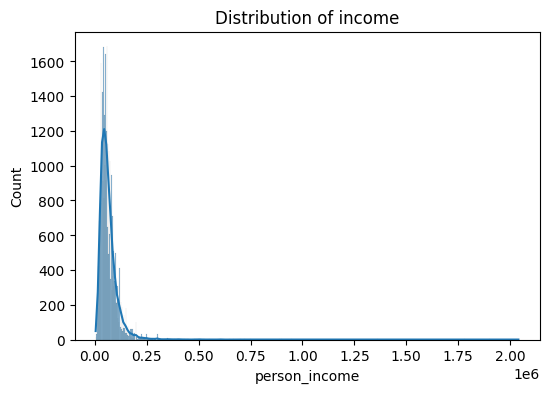

In [145]:
plt.figure(figsize=(6,4))
sns.histplot(df['person_income'], kde=True)
plt.title(f"Distribution of income")
plt.show()


#### distribution is highly right-skewed , which indicates presence of extreme outliers 
#### we remove outliers by IQR mwthod 

In [146]:
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

df = df[df['person_income'] <= upper_limit]

In [147]:
### here person_income has very high extreme outliers 

In [148]:
df['person_income'].describe()

count     31090.000000
mean      58703.299067
std       27519.968813
min        4000.000000
25%       38000.000000
50%       54000.000000
75%       75000.000000
max      140004.000000
Name: person_income, dtype: float64

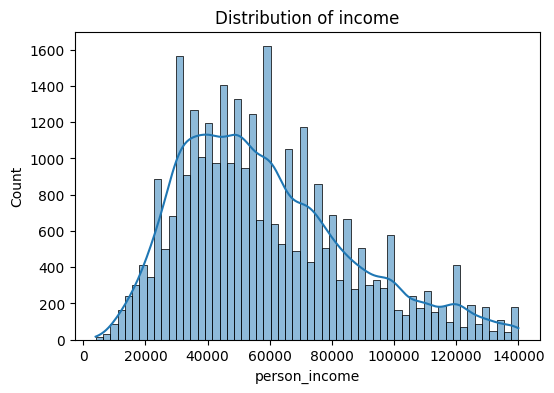

In [149]:
plt.figure(figsize=(6,4))
sns.histplot(df['person_income'], kde=True)
plt.title(f"Distribution of income")
plt.show()

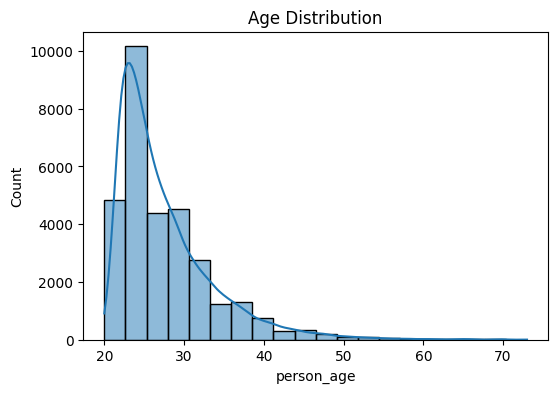

In [158]:
plt.figure(figsize=(6,4))
sns.histplot(df['person_age'], bins=20,kde=True)
plt.title(f"Age Distribution")
plt.show()


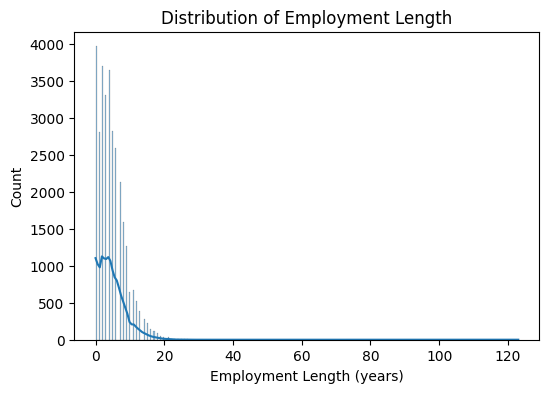

In [151]:
plt.figure(figsize=(6,4))
sns.histplot(df['person_emp_length'], kde=True)
plt.title("Distribution of Employment Length")
plt.xlabel("Employment Length (years)")
plt.show()


### here employment length ideally shold be betwwen 0 - 65 years , so we clip records which have employment length greater than 65 years 

In [152]:
df = df[df['person_emp_length'] <= 65]

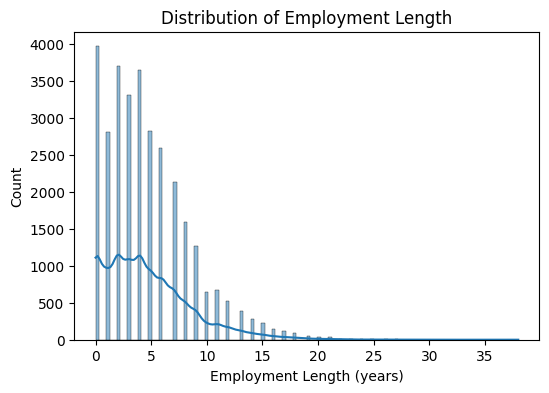

In [153]:
plt.figure(figsize=(6,4))
sns.histplot(df['person_emp_length'], kde=True)
plt.title("Distribution of Employment Length")
plt.xlabel("Employment Length (years)")
plt.show()


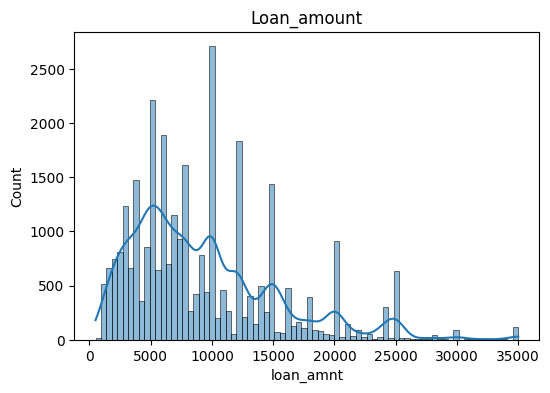

In [101]:
plt.figure(figsize=(6,4))
sns.histplot(df['loan_amnt'], kde=True)
plt.title(f"Loan_amount")
plt.show()

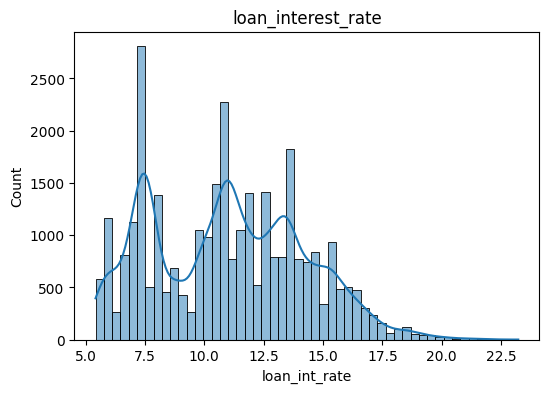

In [102]:
plt.figure(figsize=(6,4))
sns.histplot(df['loan_int_rate'], kde=True)
plt.title(f"loan_interest_rate")
plt.show()

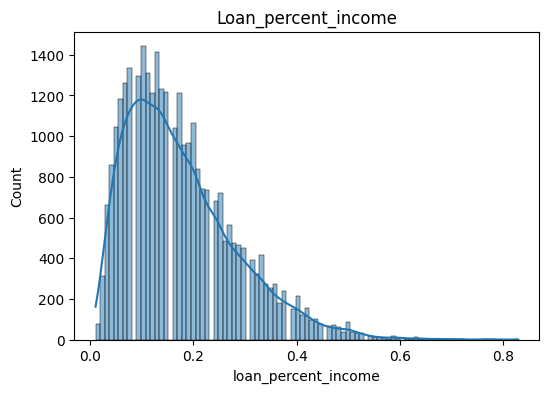

In [103]:
plt.figure(figsize=(6,4))
sns.histplot(df['loan_percent_income'], kde=True)
plt.title(f"Loan_percent_income")
plt.show()

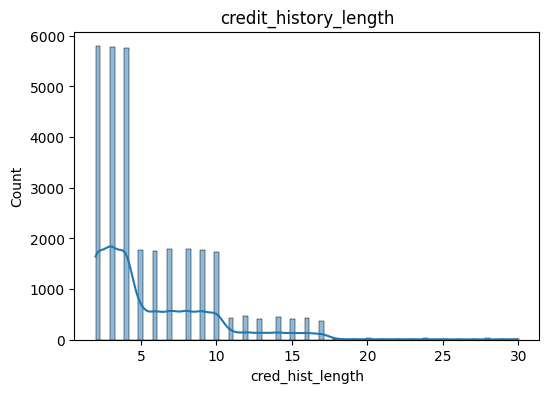

In [105]:
plt.figure(figsize=(6,4))
sns.histplot(df['cred_hist_length'],kde=True)
plt.title(f"credit_history_length")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8944\4062579825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y= df['person_home_ownership'].value_counts().index,x=df['person_home_ownership'].value_counts().values,palette='Set2')


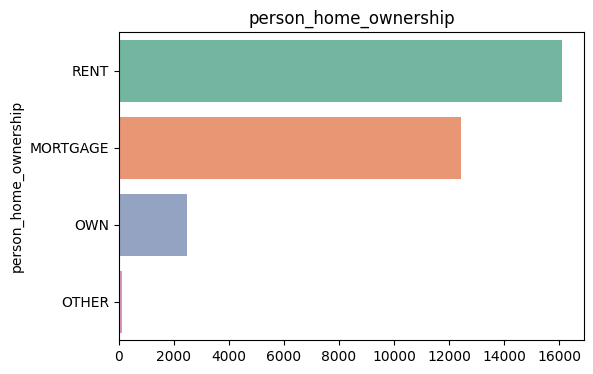

In [106]:
plt.figure(figsize=(6,4))
sns.barplot(y= df['person_home_ownership'].value_counts().index,x=df['person_home_ownership'].value_counts().values,palette='Set2')
plt.title(f"person_home_ownership")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8944\1147775131.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y= df['loan_intent'].value_counts().index,x=df['loan_intent'].value_counts().values,palette='Set1')


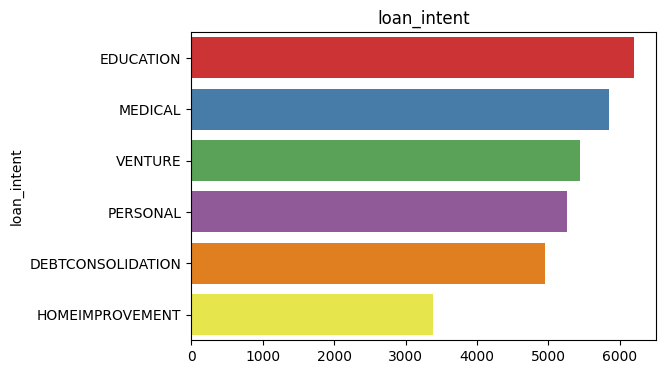

In [107]:
plt.figure(figsize=(6,4))
sns.barplot(y= df['loan_intent'].value_counts().index,x=df['loan_intent'].value_counts().values,palette='Set1')
plt.title(f"loan_intent")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8944\1987011442.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y= df['loan_grade'].value_counts().index,x=df['loan_grade'].value_counts().values,palette='coolwarm')


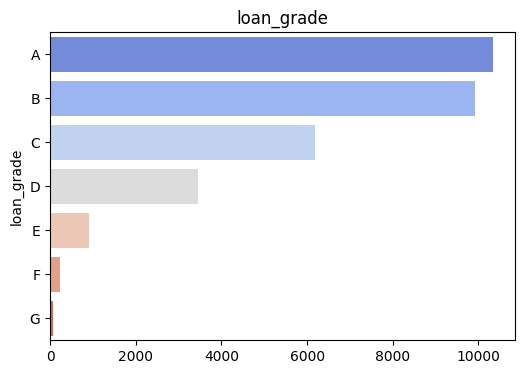

In [108]:
plt.figure(figsize=(6,4))
sns.barplot(y= df['loan_grade'].value_counts().index,x=df['loan_grade'].value_counts().values,palette='coolwarm')
plt.title(f"loan_grade")
plt.show()

### See target column distributon

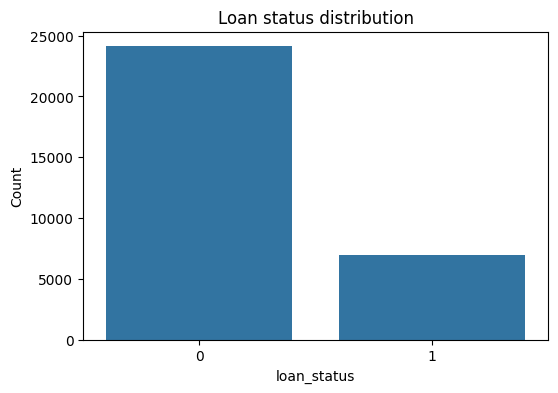

In [109]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status',data = df)
plt.title("Loan status distribution")
plt.ylabel("Count")
plt.show()

### Insights 
- Most individuals have an income in the range of ₹2 lakh to ₹8 lakh, with a peak around ₹6 lakh.
- The majority of borrowers fall in the age group of 20 to 30 years.
- Employment length is generally between 0 to 10 years, indicating a relatively early-career population.
- The most common loan amount is around ₹10,000.
- Loan interest rates are most frequently observed around 7.5%.
- Credit history length for most individuals is less than 5 years, suggesting limited credit experience.
- A large proportion of borrowers live in rented homes.
- The most common loan purpose is education.
- Most loans belong to grade A, indicating generally lower-risk borrowers.

### Bivariate Analysis 

<Axes: xlabel='loan_status', ylabel='loan_int_rate'>

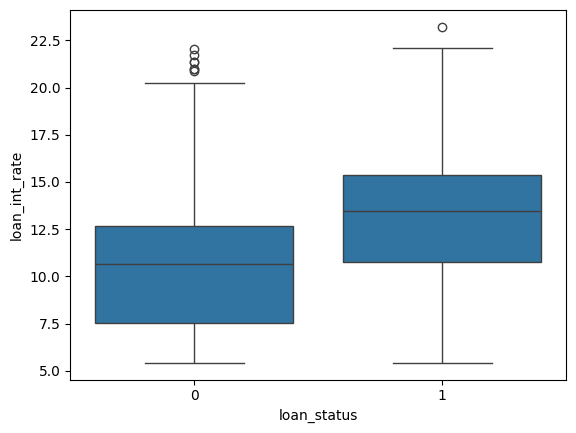

In [113]:
import seaborn as sns

sns.boxplot(x='loan_status', y='loan_int_rate', data=df)

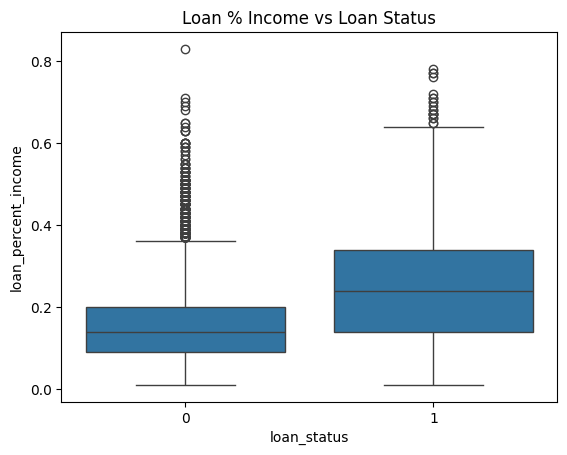

In [115]:
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.title("Loan % Income vs Loan Status")
plt.show()

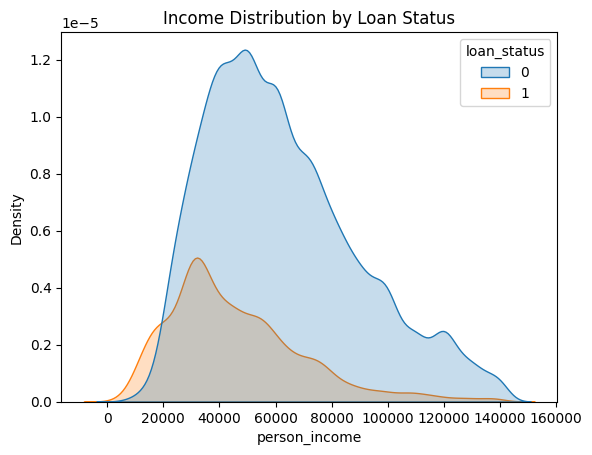

In [116]:
sns.kdeplot(data=df, x='person_income', hue='loan_status', fill=True)
plt.title("Income Distribution by Loan Status")
plt.show()

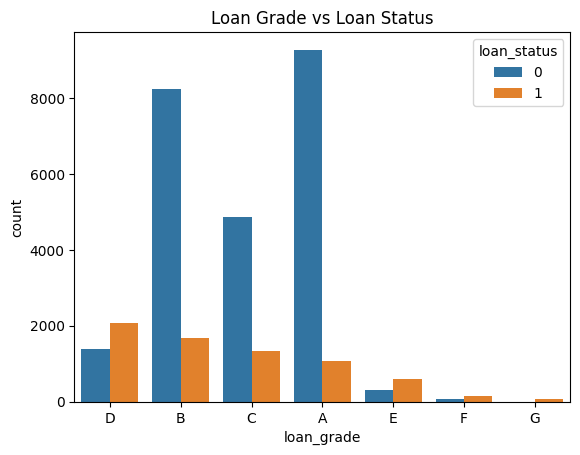

In [117]:
sns.countplot(x='loan_grade', hue='loan_status', data=df)
plt.title("Loan Grade vs Loan Status")
plt.show()

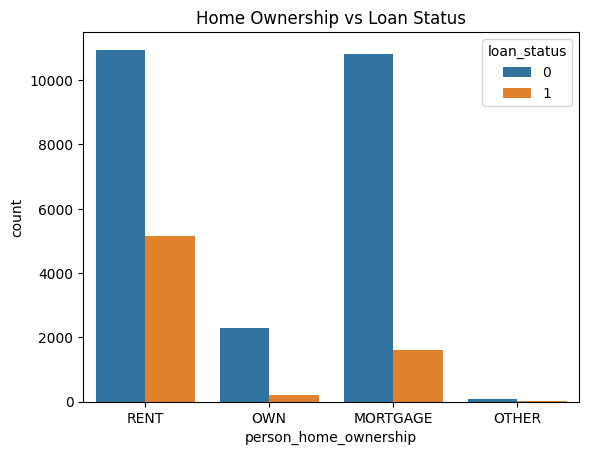

In [118]:
sns.countplot(x='person_home_ownership', hue='loan_status', data=df)
plt.title("Home Ownership vs Loan Status")
plt.show()

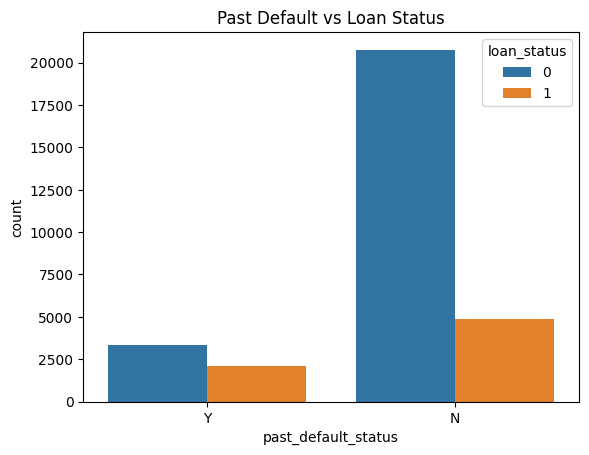

In [119]:
sns.countplot(x='past_default_status', hue='loan_status', data=df)
plt.title("Past Default vs Loan Status")
plt.show()

### Multivariate analysis

<Axes: >

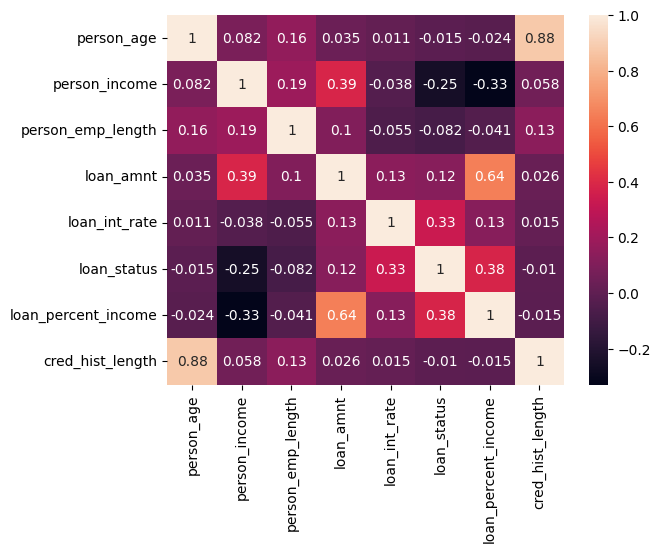

In [121]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### Insights 
- Borrowers with a higher loan-to-income ratio (loan_percent_income) are more likely to default (loan_status = 1).
- Individuals with loan grade A are less likely to default, indicating that lower-risk borrowers have better repayment behavior.
- Borrowers with home ownership status as RENT or MORTGAGE tend to have a higher proportion of non-defaulters compared to others.
- Individuals with a history of previous defaults are significantly more likely to default again, showing strong predictive power of past behavior
- Credit history length and percent_income is strongly related to person_age
